# Study the Kr response per PMT

JAH 1/05/2025

### imports

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [20]:
import os

import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [21]:
import ipywidgets as widgets
from IPython.display import display

In [22]:
import os
import sys
pypaths= ("/Users/hernando/work/investigacion/NEXT/software/nextana",
         "/Users/hernando/work/investigacion/NEXT/software/hipy",
         "/Users/hernando/work/investigacion/NEXT/software/IC")
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [23]:
import hipy.utils        as ut
import hipy.pltext       as pltext
import hipy.profile      as prof
import hipy.styles       as pltsty

In [24]:
from invisible_cities.io  . pmaps_io        import load_pmaps, load_pmaps_as_df

### configuration

### load data

In [31]:
run = 15269
path_data = "/Users/hernando/work/investigacion/NEXT/data/NEXT100"
path_run  =  f"/{run}/hdf5/prod/v2.3.1/20250429/irene/trigger1/ldc1"

In [34]:
path = path_data + path_run
#path = "/Users/hernando/work/investigacion/NEXT/data/NEXT100/15269/hdf5/prod/v2.3.1/20250429/irene/trigger1/ldc1"
filenames = os.listdir(path)
filenames = [os.path.join(path, f) for f in filenames]
#for f in filenames: print(f)

### Ana

In [62]:
## reading as DF
from collections import namedtuple

# Definimos el tipo
pmap_names = ['s1', 's2', 'si', 's1_pmt', 's2_pmt']
PMap       = namedtuple('PMap', pmap_names)

# Creamos una instancia
#electron = Particula(nombre='electrón', masa=9.11e-31, carga=-1.6e-19)

pmap = PMap(*load_pmaps_as_df(filenames[0]))

def pmap_save(pmap, filename):
    for name, df in zip(pmap_names, pmap):
        df.to_hdf(filename, key = name, mode = 'a', complevel = 9, complib = 'blosc')


def pmap_load(filename):
    pmap = PMap(*[pd.read_hdf(filename, key = name) for name in pmap_names])
    return pmap


In [118]:
kdst = pd.read_hdf(f"kdst_lowene_{run}.h5", key='kdst')
kdst_events = kdst.event.unique()
nevents     = len(kdst_events)
print(f'Total number of events in kds {nevents}')

Total number of events in kds 33517


In [125]:
nfiles = len(filenames)
progress_bar  = widgets.IntProgress(value = 0, min = 0, max = nfiles - 1, description = 'processing:')
display(progress_bar)

def _sel(df):
    return np.isin(df.event, kdst_events)

nsize = 0
pmaps = [[], [], [], [], []]
for i, file in enumerate(filenames[:nfiles]):
    progress_bar.value = i
    kpmap  = load_pmaps_as_df(file)
    sel    = _sel(kpmap[0])
    kevts  = len(kpmap[0][sel].event.unique())
    if (kevts <= 0): continue
    for j, df in enumerate(kpmap): pmaps[j].append(df[_sel(df)])
    nsize += kevts

pmap = [pd.concat(dfs) for dfs in pmaps]
    #print('file ', i, ' pmap  selected events ', len(pmap [0]     .event.unique()))


#pmap = PMap(*pmap)
print('number of saved events   ', nsize)
print('number of events in pmap ', len(pmap[0].event.unique()))


IntProgress(value=0, description='processing:', max=5210)

number of saved events    33517
number of events in pmap  33517


In [126]:
ns = [len(df.event.unique()) for df in pmap]
print(ns)

[33517, 33517, 33517, 33517, 33517]


In [127]:
pmap = PMap(*pmap)
pmap_save(pmap, f"pmap_lowene_{run}.h5")

In [141]:
s1count  = pmap.s1.groupby("event").count()
s1sum    = pmap.s1.groupby("event").sum()
s2sum    = pmap.s2.groupby("event").sum()
sisum    = pmap.si.groupby("event").sum()

In [146]:
pmap.s1.groupby("event").count()

,peak,time,bwidth,ene
event,,,,
65,22,22,22,22
86,14,14,14,14
114,84,84,84,84
135,38,38,38,38
233,6,6,6,6
...,...,...,...,...
3045128,9,9,9,9
3045163,323,323,323,323
3045268,33,33,33,33


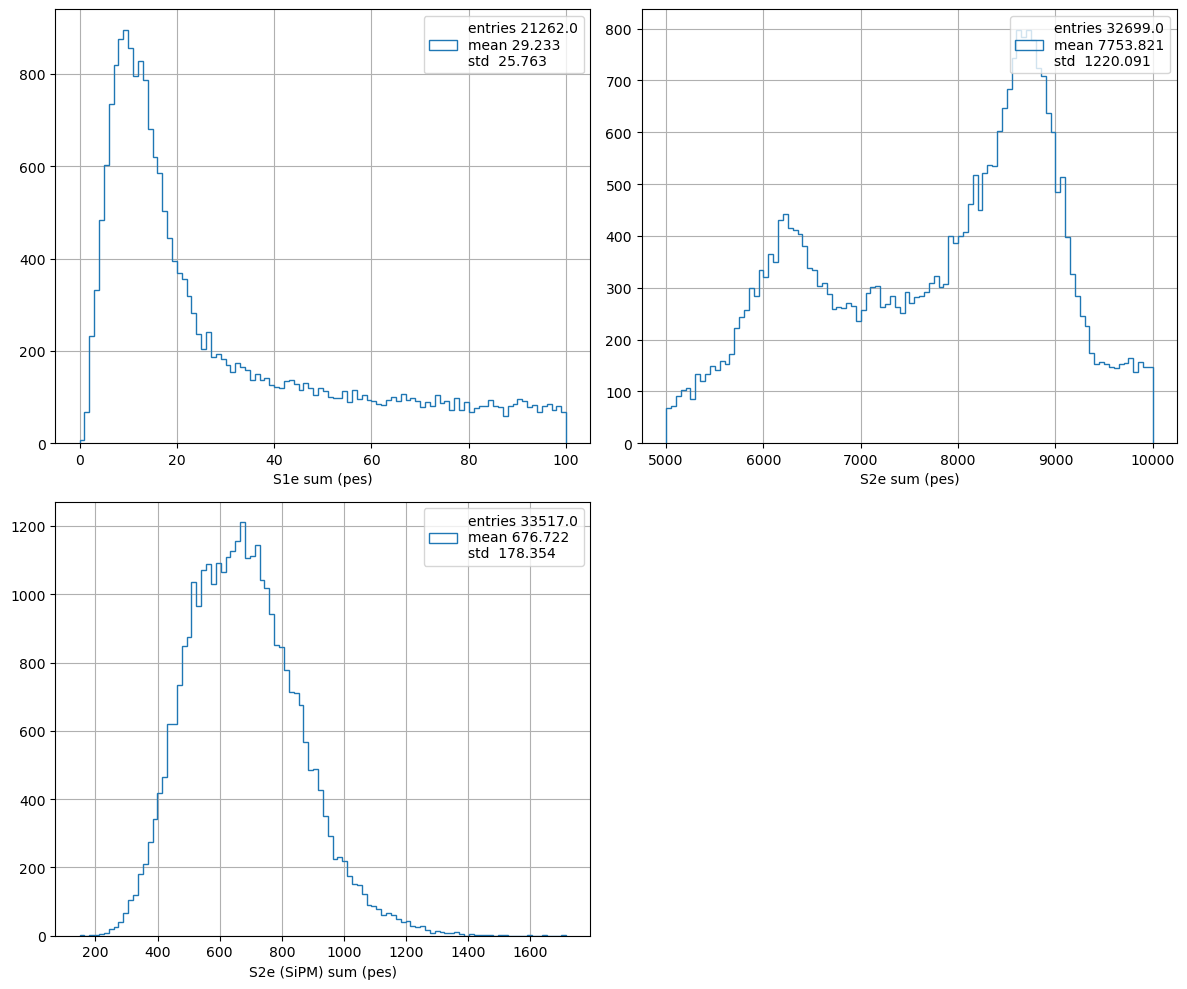

In [151]:
cv = pltext.canvas(4, 2)

cv(1); pltext.hist(s1sum.ene, 100, (0, 100)); plt.xlabel("S1e sum (pes)")
cv(2); pltext.hist(s2sum.ene, 100, (5e3, 10e3)); plt.xlabel("S2e sum (pes)")
cv(3); pltext.hist(sisum.ene, 100); plt.xlabel("S2e (SiPM) sum (pes)");
plt.tight_layout()

In [152]:
pmap.s1_pmt

,event,peak,npmt,ene
44928,2699685,0,0,-0.038015
44929,2699685,0,0,0.051259
44930,2699685,0,0,0.021501
44931,2699685,0,0,-0.008257
44932,2699685,0,0,-0.067774
...,...,...,...,...
357115,2911960,2,59,-0.050071
357116,2911960,2,59,0.015632
357117,2911960,2,59,0.048483
357118,2911960,2,59,0.081334


In [166]:
ipmt = 12
df   = pmap.s2_pmt
pmtsum = df.groupby("event npmt".split())['ene'].sum()

In [167]:
pmtsum

event    npmt
65       0       162.613266
         1       407.813293
         2       230.042801
         4       189.006363
         5       184.176895
                    ...    
3045373  54      225.980042
         55      132.640594
         56      121.201233
         57      127.229988
         59      219.876648
Name: ene, Length: 1608816, dtype: float32

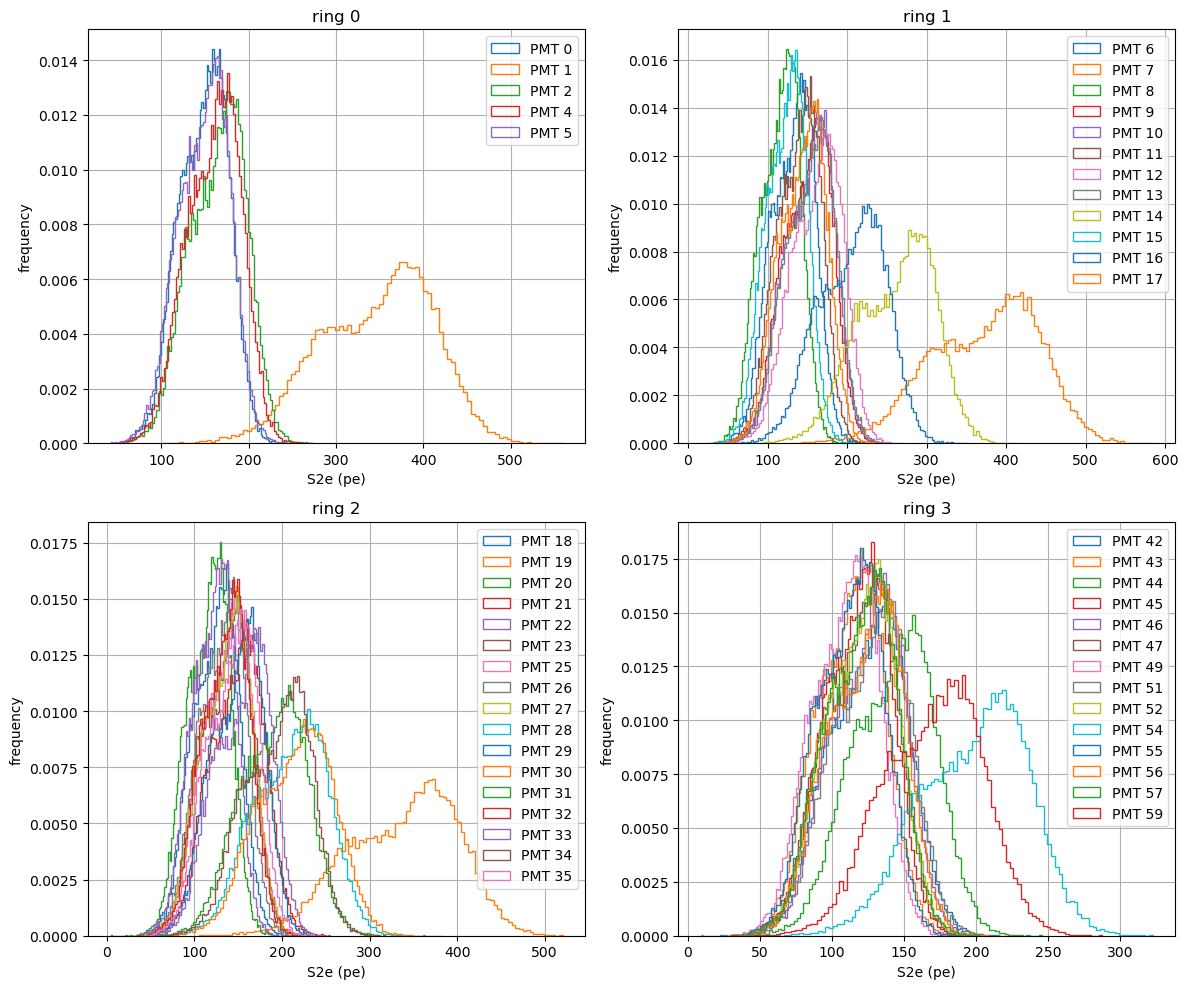

In [196]:
df   = pmap.s2_pmt
pmtsum = df.groupby("event npmt".split())['ene'].sum()

pmt_index = df.npmt.unique()
pmt_rings = [np.arange(0, 6), np.arange(6, 18), np.arange(18, 36), np.arange(36, 60)]
cv = pltext.canvas(4, 2)
for k, ids in enumerate(pmt_rings):
    cv(k+1)
    for i in ids:
        if i not in pmt_index: continue
        pltext.hist(pmtsum.xs(i, level = "npmt"), 100, density = True, stats = False, label = f"PMT {i}"); plt.xlabel("S2e (pe)");
    plt.title(f"ring {k}"); plt.ylabel("frequency");
plt.tight_layout()

In [124]:
ns = [len(kk.event.unique()) for kk in kmap]
print(ns)

[75, 68, 68, 75, 68]


In [104]:
pmap[0]

,event,peak,time,bwidth,ene
8,2699566,0,995850.0,25.0,2.003205
85,2699573,4,1342875.0,25.0,0.696384
92,2699573,4,1343050.0,25.0,0.915222
102,2699580,1,319475.0,25.0,0.795241
119,2699580,2,978875.0,25.0,0.673917
...,...,...,...,...,...
8913,2579369,2,1126775.0,25.0,0.163043
8914,2579369,2,1126800.0,25.0,-0.199402
8915,2579369,2,1126825.0,25.0,0.151625
8916,2579369,2,1126850.0,25.0,0.392832


In [114]:
#print(pmap[2].event.unique())
print(pmap[3].event.unique())
print(pmap[4].event.unique())


[2699685 2699748 2699853 2699930 2700182 2700273 2700280 1777897 1777974
 1778016 1778205 1778366 1778485 2379365 2379386 2379463 2379491 2379498
 2379575 2379694 2379743 2379750 2379820 2379827 2379848 2379883 2379946
  948880  949083  949139  949223 2144053 2144228 2144235 2144347 2144543
 3002512 3002603 3002631 3002687 3002827 3002862 3002897 3002946 1458774
 1458788 1459026 1459096 2009667 2009688 2009786 2009828 2009912 2009947
 2009961 2010010 2010122 2010255 2578788 2579005 2579201 2579369]
[2699685 2699748 2699853 2699930 2700182 2700273 2700280 1777897 1778016
 1778205 1778485 2379365 2379386 2379463 2379491 2379498 2379575 2379694
 2379743 2379820 2379827 2379848 2379883 2379946  948880  949083  949139
  949223 2144053 2144228 2144235 2144347 2144543 3002512 3002603 3002631
 3002687 3002827 3002862 3002897 1458774 1458788 1459026 1459096 2009667
 2009688 2009786 2009828 2009912 2009947 2009961 2010010 2010122 2010255
 2578788 2579005 2579201 2579369]


In [ ]:
pmap

In [ ]:
def dfs_save(s1, s2, s2)

import pandas as pd

df1.to_hdf('experimentos.h5', key='resultados_temp', mode='a',
           format='table', complevel=9, complib='blosc')

df2.to_hdf('experimentos.h5', key='resultados_presion', mode='a',
           format='table', complevel=9, complib='blosc')

df3.to_hdf('experimentos.h5', key='condiciones_iniciales', mode='a',
           format='table', complevel=9, complib='blosc')


In [ ]:
## reading as pmaps

pmaps = load_pmaps(filename)
evt = pmaps[evt_number]
evt.s1s # una lista de los s1s
evt.s2s # una lista de los s2s